# FastText 문자 n-gram과 OOV 임베딩

Word2Vec은 학습 어휘에 등록된 단어만 벡터로 조회하므로 `apple`을 배웠더라도 처음 보는 `apples`는 OOV가 된다. **FastText** 는 Word2Vec의 문맥 예측에 문자 n-gram 벡터를 추가하고, 단어 전체가 어휘에 없을 때도 이미 학습한 철자 조각을 조합해 벡터를 만든다. 형태 변화·복합어·희귀어와 일부 오탈자가 자주 등장하는 검색·분류 입력에서 이 성질을 활용할 수 있다.

이 노트북에서는 먼저 `<apple>`과 `<apples>`의 문자 3-gram을 직접 만들어 공유 조각을 확인한다. 이어서 같은 코퍼스와 기본 설정으로 Word2Vec과 FastText를 학습해 등록 여부와 OOV 벡터 생성의 차이를 분리하고, 철자 유사도와 저장·복원까지 점검한다. 마지막에는 벡터를 만들 수 있다는 사실과 그 벡터의 의미 품질이 좋다는 판단이 다르다는 한계를 바탕으로 모델 선택 기준을 정리한다.


## 01. 실습 환경 준비

gensim의 `FastText`는 Word2Vec과 비슷한 학습 인터페이스를 사용하면서 문자 n-gram 임베딩을 함께 학습한다. 같은 `sentences`, `vector_size`, `window`, `sg` 설정을 공유할 수 있어 두 모델의 OOV 처리만 비교하기 좋다. 다음 `%pip` 셀은 현재 노트북 커널에 `gensim`을 준비하며, 설치가 끝나도 새 패키지가 바로 보이지 않는 환경에서는 커널 재시작이 필요할 수 있다.

In [1]:
# %pip install -q gensim


Note: you may need to restart the kernel to use updated packages.


## 02. 문자 n-gram으로 단어 나누기

**문자 n-gram(Character n-gram)** 은 단어 안에서 연속한 $n$개의 문자를 하나의 조각으로 보는 표현이고, 이런 단어보다 작은 학습 단위를 **서브워드(Subword)** 라고 한다. FastText는 단어의 시작과 끝을 내부 위치와 구분하기 위해 경계 기호 `<`, `>`를 붙인 뒤 `min_n`부터 `max_n`까지 여러 길이의 문자 조각을 학습한다. **OOV(Out Of Vocabulary)** 는 단어 전체가 학습 어휘에 등록되지 않은 상태를 뜻하지만, 그 단어의 문자 조각 일부는 이미 학습됐을 수 있다.

예를 들어 `<apple>`의 3-gram에는 `<ap`, `app`, `ppl`, `ple`, `le>`가 포함된다. `apple`과 `apples`는 여러 문자 조각을 공유하므로 FastText는 `apples`가 OOV여도 벡터를 구성할 근거를 갖는다. 다음 직접 구현을 실행해 두 단어가 `<ap`, `app`, `ppl`, `ple`를 공유하는지 확인하면, OOV 대응이 단어를 새로 등록하는 과정이 아니라 기존 조각의 재조합이라는 점을 이해할 수 있다.

In [2]:
# 전달 받은 word를 n개로 쪼개기
def character_ngrams(word, n):

    # 단어의 시작과 끝을 다른 위치와 구분하기 위한 경계 기호를 추기
    bounded_word = f"<{word}>"

    return [
        bounded_word[start:start + n]
        for start in range(len(bounded_word) - n + 1)
    ]

apple_trigrams = character_ngrams("apple", 3)
apples_trigrams = character_ngrams("apples", 3)
shared_trigrams = sorted(set(apple_trigrams) & set(apples_trigrams))

print("apple 3-gram:", apple_trigrams)
print("apples 3-gram:", apples_trigrams)
print("공유 3-gram:", shared_trigrams)


apple 3-gram: ['<ap', 'app', 'ppl', 'ple', 'le>']
apples 3-gram: ['<ap', 'app', 'ppl', 'ple', 'les', 'es>']
공유 3-gram: ['<ap', 'app', 'ple', 'ppl']


## 03. 같은 코퍼스로 Word2Vec과 FastText 학습

두 모델의 OOV 처리 차이만 비교하기 위해 같은 문장별 토큰 목록과 같은 기본 학습 설정을 사용한다. `apples`, `teacher` 같은 변형 단어는 학습 코퍼스에 넣지 않아 이후 OOV로 조회한다.

문장을 반복하는 방식은 작은 수업 예제에서 문맥 관계를 여러 번 제공하기 위한 장치이다. 실행 후 기본 문장 수가 9, 학습 문장 수가 900이고 첫 입력이 토큰 목록이면 두 모델이 같은 중첩 입력을 받는다는 확인 기준을 만족한다. 실제 작업에서는 인위적인 반복보다 충분한 규모와 대표성을 가진 원래 코퍼스를 사용한다.

In [3]:
base_sentences = [
    ["apple", "is", "a", "sweet", "fruit"],
    ["banana", "is", "a", "yellow", "fruit"],
    ["orange", "is", "a", "fresh", "fruit"],
    ["apple", "and", "banana", "are", "fruit"],
    ["dog", "is", "a", "friendly", "animal"],
    ["cat", "is", "a", "small", "animal"],
    ["student", "learns", "from", "a", "lesson"],
    ["student", "studies", "a", "book"],
    ["teach", "a", "student", "with", "a", "book"],
]
training_sentences = base_sentences * 100

print("기본 문장 수:", len(base_sentences))
print("학습 문장 수:", len(training_sentences))
print("첫 문장:", training_sentences[0])


기본 문장 수: 9
학습 문장 수: 900
첫 문장: ['apple', 'is', 'a', 'sweet', 'fruit']


### Word2Vec과 FastText 모델 만들기

두 모델 모두 `sg=1`인 Skip-gram으로 중심 단어에서 주변 단어를 예측하고 `vector_size=40`, `window=3` 등 기본 설정을 공유한다. 차이는 Word2Vec이 등록 단어 전체를 하나의 학습 단위로 사용하는 반면 **FastText** 는 단어 벡터에 문자 n-gram 벡터를 함께 반영한다는 점이다.

FastText의 `min_n=3`, `max_n=6`은 길이 3~6의 문자 조각을 사용한다는 뜻이고, `bucket=50_000`은 수많은 문자 n-gram을 해시해 저장할 버킷 수이다. 문자 조각을 추가하면 OOV에 대응할 수 있지만 Word2Vec보다 저장·연산량이 늘고 해시 충돌 가능성도 생긴다. 다음 코드에서 두 모델의 등록 단어 행렬 shape이 같더라도 FastText의 서브워드 정보 전체가 그 shape에 드러나는 것은 아니므로, 이어지는 OOV 조회가 핵심 비교가 된다.

In [5]:
from gensim.models import FastText, Word2Vec

# Word2Vec, FastText에 공통으로 적용할 설정용 dict
common_settings = {
    "sentences": training_sentences,
    "vector_size": 40,
    "window": 3,
    "min_count": 1,
    "sg": 1,
    "negative": 5,
    "epochs": 100,
    "workers": 1,
    "seed": 42,
}

# Word2Vec 생성
# -> 등록 단어 전체를 하나의 학습 단위로 사용
word2vec_model = Word2Vec(**common_settings)

# FastText 생성
# -> 같은 문맥 학습에 길이 3~6의 문자 n-gram 벡터를 추가
fasttext_model = FastText(
    **common_settings,
    min_n=3,
    max_n=6,
    bucket=50_000,) # n-gram으로 쪼개진 서브워드를 저장할 공간

print('Word2Vec shape:', word2vec_model.wv.vectors.shape)
print('FastText shape:', fasttext_model.wv.vectors.shape)
# shape만으로는 차이점을 알 수 없음 -> OOV 조회 결과도 함께 봐야지만 차이를 알 수 있음

Word2Vec shape: (24, 40)
FastText shape: (24, 40)


## 04. 등록 단어와 OOV 벡터 비교

Word2Vec은 `apples`가 어휘에 없으면 해당 단어의 벡터를 조회할 수 없다. FastText도 `apples`를 등록 어휘로 취급하지는 않지만 학습한 문자 n-gram을 조합해 40차원 벡터를 반환한다.

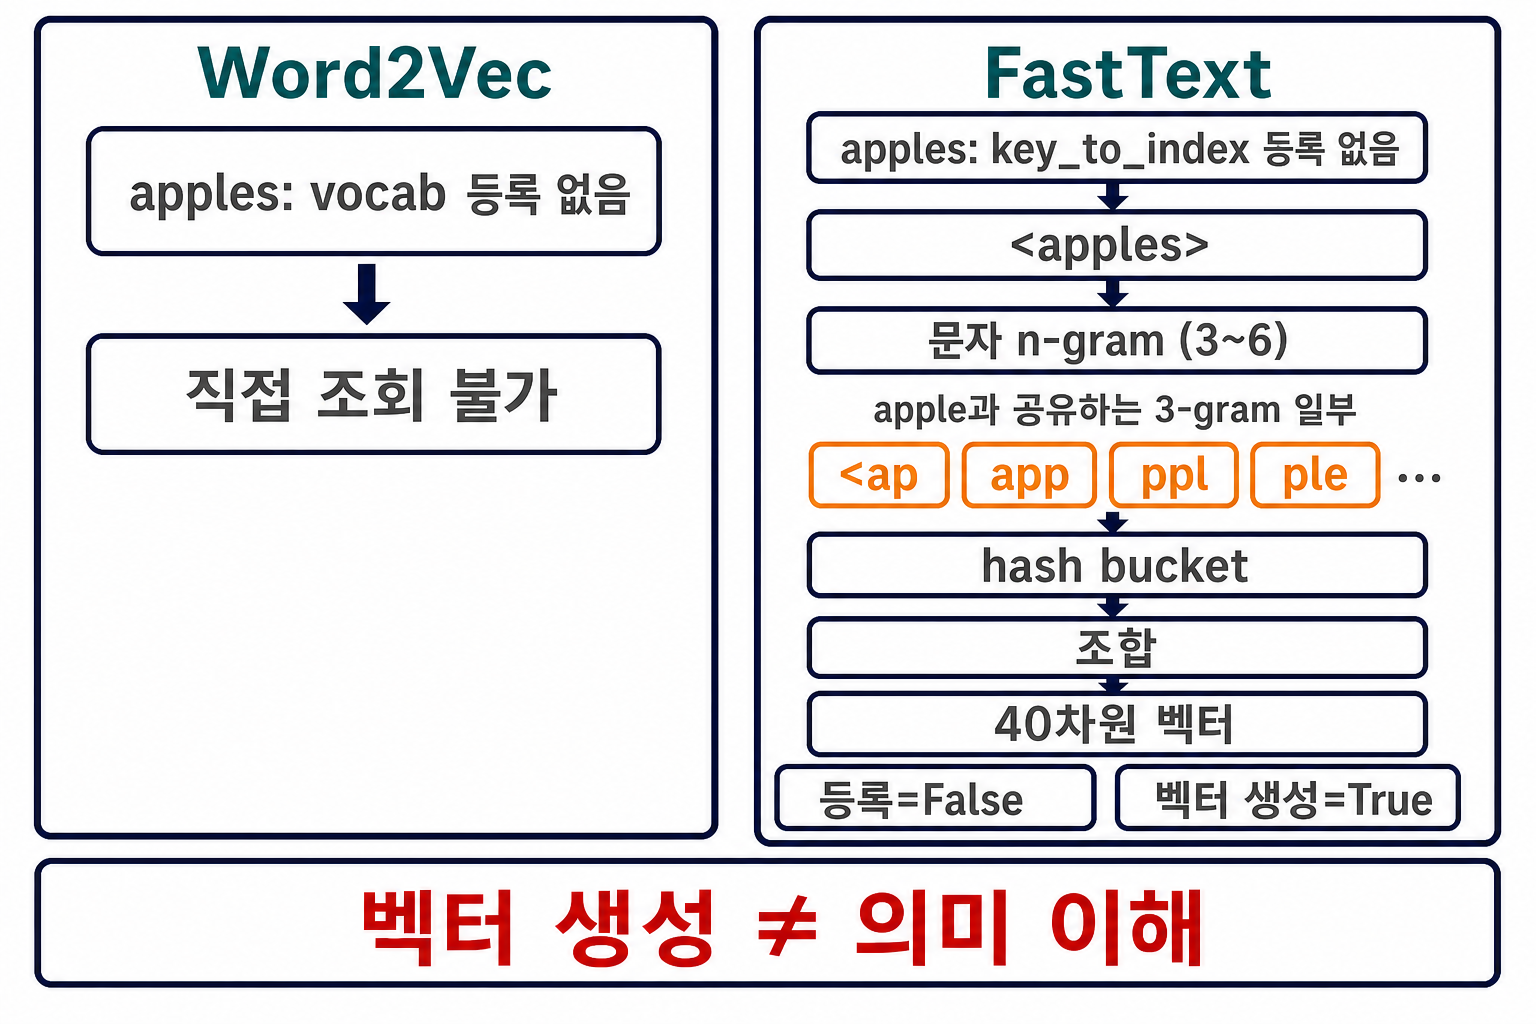

주황색 네 조각은 `apple`과 공유하는 3-gram의 일부이며, 실제 FastText는 나머지 3~6글자 조각도 hash bucket을 통해 함께 사용한다. 따라서 `apples`는 등록 단어가 아니어도 벡터를 만들 수 있다. 그러나 벡터 생성과 단어 의미 이해는 서로 다른 판단이다.

FastText가 OOV 벡터를 반환한다는 사실과 그 벡터의 의미 품질이 좋다는 판단은 구분해야 한다. 실행 후 `apples`, `teacher`가 `key_to_index`에는 없지만 `get_vector()`가 길이 40의 벡터를 반환한다면 서브워드 조합 경로가 동작한 것이다. 그 벡터가 작업에 유용한지는 학습 코퍼스에서 충분한 문자 조각을 관찰했는지와 새 단어의 철자 구조가 의미 있는지를 별도로 검증해야 한다.

In [6]:
# Word2Vec과 FastText에서 등록 단어·OOV의 포함 여부와 벡터 생성을 비교한다.

for word in ["apple", "apples", "teacher"]:
    print(
        word,
        "| Word2Vec 등록:", word in word2vec_model.wv,
        "| FastText 등록:", word in fasttext_model.wv.key_to_index,
    )

# FastText는 등록 여부와 관계없이 문자 n-gram으로 40차원 벡터를 만든다.
apple_vector = fasttext_model.wv.get_vector("apple")
apples_vector = fasttext_model.wv.get_vector("apples")
teacher_vector = fasttext_model.wv.get_vector("teacher")

print("apple 벡터 shape:", apple_vector.shape)
print("apples OOV 벡터 shape:", apples_vector.shape)
print("teacher OOV 벡터 shape:", teacher_vector.shape)

apple | Word2Vec 등록: True | FastText 등록: True
apples | Word2Vec 등록: False | FastText 등록: False
teacher | Word2Vec 등록: False | FastText 등록: False
apple 벡터 shape: (40,)
apples OOV 벡터 shape: (40,)
teacher OOV 벡터 shape: (40,)


### 철자가 비슷한 단어의 유사도

`similarity()`는 등록 단어뿐 아니라 FastText가 구성한 OOV 벡터에도 코사인 유사도를 계산할 수 있다. `apple-apples`와 `teach-teacher`는 철자 조각을 많이 공유하므로 관련 없는 `apple-teacher`보다 높은 값이 나오는지 비교한다.

이 비교는 FastText의 동작 원리를 확인하는 예이다. 실행 후 `apple-apples`와 `teach-teacher`가 관련 없는 `apple-teacher`보다 높은지 비교하면 공유 문자 조각의 영향을 읽을 수 있다. 기대한 순서가 나오지 않더라도 즉시 코드 오류로 단정하지 않고 작은 코퍼스의 문맥 부족, 난수 학습과 실제 n-gram 공유 정도를 함께 점검한다. 철자가 비슷하지만 의미가 다른 단어나 표기 체계가 다른 언어에서는 문자 유사성이 의미 유사성을 잘못 높일 수 있다.

In [7]:
print(
    "apple-apples:",
    round(float(fasttext_model.wv.similarity("apple", "apples")), 4),
)
print(
    "teach-teacher:",
    round(float(fasttext_model.wv.similarity("teach", "teacher")), 4),
)
print(
    "apple-teacher:",
    round(float(fasttext_model.wv.similarity("apple", "teacher")), 4),
)

# 사전에는 없지만 벡터에는 등록이 되어 있다.

apple-apples: 0.9872
teach-teacher: 0.9999
apple-teacher: 0.1375


## 05. FastText 저장과 복원

`model.save()`는 등록 단어 벡터뿐 아니라 문자 n-gram과 모델 설정을 포함한 전체 FastText 모델을 저장한다. OOV 벡터 생성 기능을 유지하려면 단어 벡터만 내보내는 방식보다 전체 모델 저장이 적합하다. 실행 후 복원된 등록 단어 행렬 shape이 같고 저장 전후 `apples` OOV 벡터의 `np.allclose()` 결과가 `True`이면 서브워드 정보까지 함께 복원됐다고 판단할 수 있다.

In [8]:
import numpy as np

model_path = "fasttext_compact.model"
fasttext_model.save(model_path)
restored_fasttext = FastText.load(model_path)

same_oov_vector = np.allclose(
    fasttext_model.wv.get_vector("apples"),
    restored_fasttext.wv.get_vector("apples"),
)

print("저장 파일:", model_path)
print("복원 등록 단어 shape:", restored_fasttext.wv.vectors.shape)
print("apples OOV 벡터 동일:", same_oov_vector)


저장 파일: fasttext_compact.model
복원 등록 단어 shape: (24, 40)
apples OOV 벡터 동일: True


## 06. Word2Vec과 FastText 선택 기준

Word2Vec과 FastText는 모두 문맥 예측으로 정적 단어 벡터를 학습하지만, 새 단어를 처리하는 단위와 비용이 다르다. 실제 선택은 다음 기준을 함께 본다.

### Word2Vec을 먼저 고려하는 경우

(* 등록 외 단어 즉 등록되지 않은/유사한 단어를 찾을 수 없고, 벡터화 하지 않음. 비용적으로는 절감.)
- 학습 단위: 등록된 단어 전체
- OOV 처리: 등록되지 않은 단어의 벡터를 직접 만들 수 없음
- 적합한 데이터: 어휘가 충분히 정제되어 있고 학습 후 새 단어가 자주 나타나지 않는 데이터
- 비용과 위험: 구조가 비교적 단순하지만 OOV 비율이 높으면 많은 입력을 표현하지 못함

### FastText를 먼저 고려하는 경우

(* 비용적으로는 word2vec보다 더 소모되지만, 등록 외 유사 단어를 찾을 수 있음)
- 학습 단위: 등록 단어와 단어 내부의 문자 n-gram
- OOV 처리: 학습한 문자 조각을 조합해 미등록 단어의 벡터를 구성함
- 적합한 데이터: 활용·파생·복합어·희귀어와 철자 변형이 자주 나타나는 데이터
- 비용과 위험: 저장·연산량이 증가하고 **뜻이 완전히 다른데 철자가 비슷한 단어의 의미 유사도를 과대평가**할 수 있음

FastText의 OOV 벡터는 문자 조각에서 추정한 값이므로 새 단어의 실제 뜻을 이해했다는 의미가 아니다. 숫자·임의 문자열·철자는 비슷하지만 뜻이 다른 단어에서도 벡터를 만들며, 학습 코퍼스의 편향도 그대로 반영한다. 최종 선택은 OOV 비율뿐 아니라 분류·검색 같은 실제 작업 성능으로 검증한다.